<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [ ]:
!pip install -q gdown torch transformers accelerate bitsandbytes scikit-learn langchain sentence-transformers openpyxl datasets langchain-community ragatouille --use-deprecated=legacy-resolver

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 10.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 30.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 54.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 18.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 73.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from langchain.docstore.document import Document as LangchainDocument
#from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
#from langchain.vectorstores import FAISS
#from langchain_community.embeddings import HuggingFaceEmbeddings
#from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
import seaborn as sns
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import sklearn

import sys
from transformers import optimization as transformers_optim
from torch.optim import AdamW
# Подменяем AdamW в transformers, чтобы RAGPretrainedModel работал
sys.modules["transformers"].AdamW = AdamW
sys.modules["transformers"].optimization.AdamW = AdamW
from ragatouille import RAGPretrainedModel

pd.set_option("display.max_colwidth", None)


#------------------------------------------------------------------------------------
# from langchain.text_splitter import ... # выберите другую стратегию разбивки на чанки

# pd.set_option("display.max_colwidth", None)

Если установить langchain до импортов, то происходит ошибка: pandas не импортируется.

In [ ]:
!pip install umap-learn

In [ ]:
import umap

In [ ]:
!pip install --quiet --upgrade sentence_transformers --use-deprecated=legacy-resolver #

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.7/345.7 kB 18.4 MB/s eta 0:00:00


In [ ]:
!pip -q install langchain-chroma #--use-deprecated=legacy-resolver

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 6.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.1/611.1 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 6.1 MB/s eta 0:00

In [ ]:
device = 'cuda' if torch.cuda.is_available() else "cpu"

## Загрузка данных (4 балла)

In [ ]:
url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'file.csv'

gdown.download(url, output, quiet=False)

data = pd.read_csv('file.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk
From (redirected): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk&confirm=t&uuid=688a7cd1-cc73-42e0-ba4a-756028647fc8
To: /content/file.csv
100%|██████████| 672M/672M [00:27<00:00, 24.4MB/s]


В данных 14634 строки.

Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [ ]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [ ]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

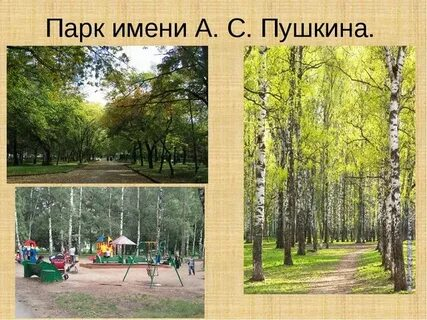

In [ ]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [ ]:
# tf-idf analysis
corpus = list(data['en_txt'])

from sklearn.feature_extraction.text import TfidfVectorizer

# Создание объекта TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Применение TF-IDF к текстовым данным
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

# Получение списка ключевых слов и их значения TF-IDF для первого документа
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_scores = tfidf_matrix.toarray()[0]

# Сортировка слов по значениям TF-IDF
sorted_keywords = {word: score for score, word in sorted(zip(tfidf_scores, feature_names), reverse=True)}

print("Ключевые слова:", sorted_keywords)

Ключевые слова: {'track': np.float64(0.519289243340565), 'are': np.float64(0.4655480267966225), 'stadium': np.float64(0.4278678287088605), 'that': np.float64(0.28338037726985565), 'two': np.float64(0.2774826730969835), 'standing': np.float64(0.2468252985668775), 'people': np.float64(0.2413019494724379), 'there': np.float64(0.1412527158845316), 'on': np.float64(0.1332708296835676), 'in': np.float64(0.12794124800367063), 'сралнннннн': np.float64(0.0), 'прррмомоннннннннннн': np.float64(0.0), 'zoo': np.float64(0.0), 'zebra': np.float64(0.0), 'zazne': np.float64(0.0), 'young': np.float64(0.0), 'you': np.float64(0.0), 'york': np.float64(0.0), 'yevava': np.float64(0.0), 'yellow': np.float64(0.0), 'year': np.float64(0.0), 'yard': np.float64(0.0), 'wrought': np.float64(0.0), 'wrong': np.float64(0.0), 'writing': np.float64(0.0), 'wrist': np.float64(0.0), 'wrestling': np.float64(0.0), 'wreaths': np.float64(0.0), 'wreath': np.float64(0.0), 'world': np.float64(0.0), 'working': np.float64(0.0), 'wor

In [ ]:
print("Top-20 words")
for i in range(20):
  print(list(sorted_keywords.keys())[i])
print()
print("Last 20 words")
for i in range(1, 20):
  print(list(sorted_keywords.keys())[-i])

Top-20 words
track
are
stadium
that
two
standing
people
there
on
in
сралнннннн
прррмомоннннннннннн
zoo
zebra
zazne
young
you
york
yevava
yellow

Last 20 words
1000
100th
123
1930s
33
3d
4k
abandoned
about
above
academy
accordion
across
action
adults
advertisement
advertising
aerial
against


В первых 20 есть странные слова 'сралнннннн' и 'прррмомоннннннннннн'. Интересно, а в каких они описаниях?

In [ ]:
[(i, x) for i, x in enumerate(list(corpus)) if 'сралнннннн' in x or 'прррмомоннннннннннн' in x]

[(9958, 'сралнннннн - cerque apttapa album'), (14353, 'прррмомоннннннннннн')]

In [ ]:
data.drop(columns=['image']).iloc[9958]

,9958
Unnamed: 0,3462
Name,Сердце
WikiData,NaN
City,Владимир
Lon,40.410282
Lat,56.12999
description,NaN
en_txt,сралнннннн - cerque apttapa album


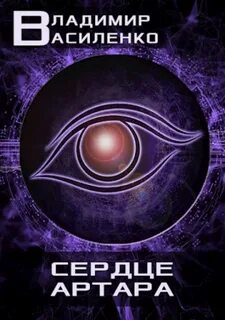

In [ ]:
get_image(data['image'].iloc[9958])

In [ ]:
data.drop(columns=['image']).iloc[14353]

,14353
Unnamed: 0,4091
Name,Ярославский дворец молодёжи
WikiData,Q4538877
City,Ярославль
Lon,39.867222
Lat,57.63625
description,Ярославский дворец молодёжи
en_txt,прррмомоннннннннннн


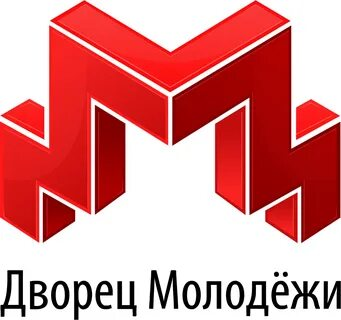

In [ ]:
get_image(data['image'].iloc[14353])

9958 - это книга, явно попала в данные по ошибке, 14353 - несоответствующее описание реального объекта. Удалю обе строки.

Посмотрим, есть ли пропуски в данных

In [ ]:
# 14634 rows
data.isna().sum(axis=0)

,0
Unnamed: 0,0
Name,0
WikiData,2556
City,0
Lon,0
Lat,0
description,2556
image,0
en_txt,0


<Axes: >

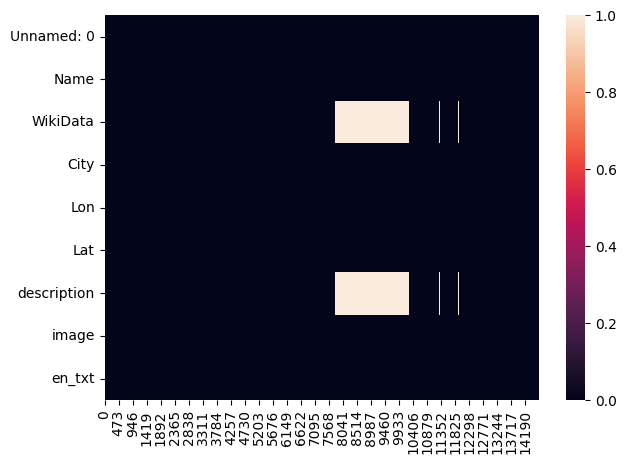

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(data.isna().transpose())

Все объекты с пропусками имеют их и в викиданных и в описании. Учитывая, что нам нужно всего 100 образцов, можно смело удалить все объекты с пропусками.

In [ ]:
data_cleaned = data.drop(labels=[9958, 14353])
data_cleaned = data_cleaned.dropna()

In [ ]:
data['City'].value_counts()

,count
City,
Ярославль,4372
Владимир,3511
Нижний Новгород,3469
Екатеринбург,3282


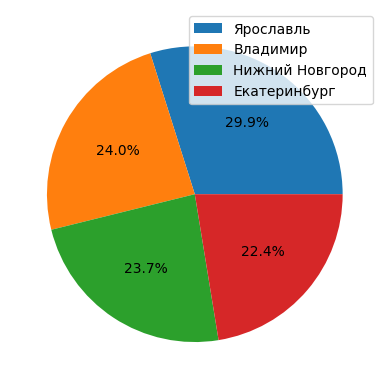

In [ ]:
plt.pie(data['City'].value_counts(), autopct='%1.1f%%')
plt.legend(data['City'].value_counts().index, loc = 'upper right')
plt.show()

In [ ]:
data_cleaned['City'].value_counts()

,count
City,
Ярославль,4287
Нижний Новгород,3469
Екатеринбург,3282
Владимир,1039


In [ ]:
cities = data_cleaned['City'].value_counts().index.to_list()

Города в базе всего 4, в неочищенном датасете их доли примерно одинаковы. Большая часть удаленных объектов была из Владимира, остальные тоже затронуло, но менее чем на 100 штук каждый. Для равномерности возьму из всех городов одинаковое число примеров. Во Владимире более 25 объектов, так что возьму из каждого по самому длинному описанию и потом по столько же - из других городов.

In [ ]:
for city in cities:
  print(city)
  print(data_cleaned[data_cleaned['City'] == city]['Name'].value_counts())
  print()

Ярославль
Name
Дом муз                                 60
М.В. Фрунзе                             60
Знаменская церковь                      60
Школа № 33 имени Карла Маркса           60
Церковь Николая Надеина                 60
                                        ..
Николо-Тропинская церковь               27
Ярославское художественное училище      27
Ярославский дворец молодёжи             27
Дом Болконского                         26
Тимерёвский археологический комплекс    26
Name: count, Length: 96, dtype: int64

Нижний Новгород
Name
Чкаловская лестница                                            82
Музей-квартира А.М. Горького                                   60
Храм Живоначальной Троицы                                      60
Церковь во имя Всемилостивейшего Спаса                         60
Борисоглебская башня                                           60
                                                               ..
Рекорд                                                  

In [ ]:
data_cleaned[data_cleaned['City'] == city]['Name'].unique()

array(['Церковь Никиты Великомученика', 'Авиамеханический колледж',
       'Собор Успения Пресвятой Богородицы', 'Троицкая церковь',
       'Дом-музей Столетовых', 'Исторический музей',
       'Князь-Владимирская церковь',
       'Владимирский академический областной драматический театр',
       'Здание Присутственных мест. "Палаты"',
       'Бывшая водонапорная башня',
       'Костел Святого Розария Пресвятой Девы Марии Римско-Католической Церкви',
       'Дмитриевский собор',
       'Богородице-Рождественский мужской монастырь',
       'Успенский Княгинин монастырь', 'Золотые ворота',
       'Владимирский централ',
       'Владимирский государственный гуманитарный университет',
       'Владимирское духовное училище',
       'Белокаменные памятники Владимира и Суздаля',
       'Владимирский планетарий', 'Храм Казанской иконы Божией Матери',
       'Здание городской думы', 'Музей ложки',
       'Князь-Владимирское кладбище', 'Владимирская митрополия',
       'Владимиро-Суздальский музе

In [ ]:
num_examples = len(data_cleaned[data_cleaned['City'] == "Владимир"]['Name'].unique())
num_examples

29

In [ ]:
from IPython.display import clear_output

dataset = []
for city in cities:
  names = data_cleaned[data_cleaned['City'] == city]["Name"].value_counts()[:num_examples].index

  for name in names:
    inner_df = data_cleaned[data_cleaned['City'] == city][data_cleaned["Name"] == name]
    inner_df['Len'] = inner_df['en_txt'].apply(lambda x: len(x))
    row = inner_df.loc[inner_df['Len'].idxmax()]
    row = row.drop(columns='Len')
    dataset.append(row)
clear_output()

In [ ]:
dataset_df = pd.DataFrame(dataset)

А теперь посмотрим глазами на en_text наших объектов.

In [ ]:
dataset_df.drop(columns='image')

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,en_txt,Len
11284,1022,Дом муз,Q4165529,Ярославль,39.869602,57.624615,Дом муз,a picture of a picture of a picture of a picture of a picture of a picture of a,79
11741,1479,М.В. Фрунзе,Q4343266,Ярославль,39.874001,57.599037,Памятник Михаилу Фрунзе (Ярославль),arafed apartment building with snow on the ground and a person walking in front,79
11353,1091,Знаменская церковь,Q4113610,Ярославль,39.885262,57.625439,Крепостная башня в Ярославле,cars are parked in front of a large white building with a golden dome,69
14255,3993,Школа № 33 имени Карла Маркса,Q4525185,Ярославль,39.881363,57.628075,Школа № 33 имени Карла Маркса,there is a building with a green and white facade and a sign that says school of management,91
13782,3520,Церковь Николая Надеина,Q4504840,Ярославль,39.896023,57.628815,Православный храм в Ярославле,arafed doorway in a church with a painting of jesus and other religious figures,79
...,...,...,...,...,...,...,...,...,...
7076,325,Владимирский академический областной драматический театр,Q56230588,Владимир,40.396076,56.125618,театр города Владимира,people walking in front of a building with a clock tower in the background,74
7691,940,Владимиро-Суздальский музей-заповедник (центральный офис),Q4113090,Владимир,40.409889,56.130569,Владимиро-Суздальский музей-заповедник,aerial view of a large white church with blue domes in a green field,68
7105,354,"Здание Присутственных мест. ""Палаты""",Q21639730,Владимир,40.410210,56.128372,Здание присутственных мест,a view of a large building with a golden dome in the middle of a park,69
7296,545,Успенский Княгинин монастырь,Q4478034,Владимир,40.398716,56.131477,Успенский Княгинин монастырь,arafed white building with a green roof and a white fence,57


В начале многих описаний есть странное слово arafed, удалю его.

In [ ]:
dataset_df['en_txt'] = dataset_df['en_txt'].apply(lambda x: ' '.join(x.split()[1:]) if x.startswith("araf") else x)
#dataset_df.drop(columns='image')

Вручную почистил данные от описаний, которые слишком подробно описывают детали фото, не относящиеся к достопримечательности.

In [ ]:
bad_texts = ['a picture of a picture of a picture of a picture of a picture of a picture of a',
             'apartment building with snow on the ground and a person walking in front',
             'man kneeling down in front of a flag while a man in a blue uniform knee',
             'snowy street with a church in the background and a person walking in the snow',
             'a group of people standing in front of a building with a large group of musicians',
             'a black and white photo of a group of people standing around a statue',
             'there is a black and white photo of a building with a horse and carriage',
             'a computer generated image of a rocky landscape with a moon in the distance',
             'there is a cat walking in front of a building with a bird on the ground',
             'people walking in front of a building with a sign that says university of engineering', # это гуманитарный университет, не могу смириться, что его обозвали инженерным
             'man with a white beard and a blue and gold robe sitting next to a man'
             ]
dataset_df['en_txt'] = dataset_df['en_txt'].apply(lambda x: x if x not in bad_texts else np.nan)
dataset_df.dropna(inplace=True)
#dataset_df['en_txt'].to_list()

In [ ]:
dataset_df.to_csv('dataset.csv', index=True)

In [ ]:
dataset_df.drop(columns='image')

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,en_txt,Len
11353,1091,Знаменская церковь,Q4113610,Ярославль,39.885262,57.625439,Крепостная башня в Ярославле,cars are parked in front of a large white building with a golden dome,69
14255,3993,Школа № 33 имени Карла Маркса,Q4525185,Ярославль,39.881363,57.628075,Школа № 33 имени Карла Маркса,there is a building with a green and white facade and a sign that says school of management,91
13782,3520,Церковь Николая Надеина,Q4504840,Ярославль,39.896023,57.628815,Православный храм в Ярославле,doorway in a church with a painting of jesus and other religious figures,79
13650,3388,церковь Иоанна Предтечи в Толчкове,Q2084804,Ярославль,39.856861,57.610909,Православный храм в Ярославле,aerial view of a church with a green roof and a river in the background,71
13126,2864,Ф. Г. Волкову,Q4343395,Ярославль,39.883522,57.626495,Памятник в Ярославле,there is a large yellow building with a green roof and a lot of cars parked in front of,87
...,...,...,...,...,...,...,...,...,...
7628,877,Князь-Владимирское кладбище,Q19691959,Владимир,40.434685,56.143505,некрополь во Владимире,brick building with a gate and sign that says brainhoofe kalming,71
7076,325,Владимирский академический областной драматический театр,Q56230588,Владимир,40.396076,56.125618,театр города Владимира,people walking in front of a building with a clock tower in the background,74
7691,940,Владимиро-Суздальский музей-заповедник (центральный офис),Q4113090,Владимир,40.409889,56.130569,Владимиро-Суздальский музей-заповедник,aerial view of a large white church with blue domes in a green field,68
7105,354,"Здание Присутственных мест. ""Палаты""",Q21639730,Владимир,40.410210,56.128372,Здание присутственных мест,a view of a large building with a golden dome in the middle of a park,69


102 образца, в самый раз.

Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

Для придания описаниям конкретики я добавлю к ним переведенные на английский название и город объекта

In [ ]:
from transformers import MarianMTModel, MarianTokenizer

# Load model and tokenizer
model_name = 'Helsinki-NLP/opus-mt-ru-en'
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

def translate_ru_to_en(text):
    # Tokenize input
    tokens = tokenizer.prepare_seq2seq_batch([text], return_tensors="pt")
    # Generate translation
    translation = model.generate(**tokens)
    # Decode output
    translated_text = tokenizer.decode(translation[0], skip_special_tokens=True)
    return translated_text

def replace_city(text): # никаких Lower Novgorod
    translations = {"Ярославль": 'Yaroslavl', "Екатеринбург": 'Ekaterinburg', "Нижний Новгород": 'Nizhniy Novgorod', "Владимир": 'Vladimir'}
    return translations[text]


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/803k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.38k [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


pytorch_model.bin:   0%|          | 0.00/307M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

In [ ]:
dataset_df['en_txt'] = dataset_df.apply(lambda x: f"The {translate_ru_to_en(x['Name'])} in city of {replace_city(x['City'])} is a {translate_ru_to_en(x['description'])}, its photo could be described as {x['en_txt']}", axis=1)

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:4106: FutureWarning: 
`prepare_seq2seq_batch` is deprecated and will be removed in version 5 of HuggingFace Transformers. Use the regular
`__call__` method to prepare your inputs and targets.

Here is a short example:

model_inputs = tokenizer(src_texts, text_target=tgt_texts, ...)

If you either need to use different keyword arguments for the source and target texts, you should do two calls like
this:

model_inputs = tokenizer(src_texts, ...)
labels = tokenizer(text_target=tgt_texts, ...)
model_inputs["labels"] = labels["input_ids"]

See the documentation of your specific tokenizer for more details on the specific arguments to the tokenizer of choice.
For a more complete example, see the implementation of `prepare_seq2seq_batch`.

  warnings.warn(formatted_warning, FutureWarning)


model.safetensors:   0%|          | 0.00/307M [00:00<?, ?B/s]

In [ ]:
dataset_df.drop(columns='image')

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,en_txt,Len
11353,1091,Знаменская церковь,Q4113610,Ярославль,39.885262,57.625439,Крепостная башня в Ярославле,"The Celebrity Church in city of Yaroslavl is a The Fortress Tower in Jaroslava, its photo could be described as cars are parked in front of a large white building with a golden dome",69
14255,3993,Школа № 33 имени Карла Маркса,Q4525185,Ярославль,39.881363,57.628075,Школа № 33 имени Карла Маркса,"The Carl Marx School No. 33 in city of Yaroslavl is a Carl Marx School No. 33, its photo could be described as there is a building with a green and white facade and a sign that says school of management",91
13782,3520,Церковь Николая Надеина,Q4504840,Ярославль,39.896023,57.628815,Православный храм в Ярославле,"The Nikolai Nadiin Church in city of Yaroslavl is a Orthodox Temple in Jaroslava, its photo could be described as doorway in a church with a painting of jesus and other religious figures",79
13650,3388,церковь Иоанна Предтечи в Толчкове,Q2084804,Ярославль,39.856861,57.610909,Православный храм в Ярославле,"The The Church of John Predekchi in Tolčka in city of Yaroslavl is a Orthodox Temple in Jaroslava, its photo could be described as aerial view of a church with a green roof and a river in the background",71
13126,2864,Ф. Г. Волкову,Q4343395,Ярославль,39.883522,57.626495,Памятник в Ярославле,"The F. G. Volkov in city of Yaroslavl is a A memorial in Jaroslavla, its photo could be described as there is a large yellow building with a green roof and a lot of cars parked in front of",87
...,...,...,...,...,...,...,...,...,...
7628,877,Князь-Владимирское кладбище,Q19691959,Владимир,40.434685,56.143505,некрополь во Владимире,"The Prince Vladimier Cemetery in city of Vladimir is a Necropolis in Vladimir, its photo could be described as brick building with a gate and sign that says brainhoofe kalming",71
7076,325,Владимирский академический областной драматический театр,Q56230588,Владимир,40.396076,56.125618,театр города Владимира,"The Vladimir Academic Regional Drama Theatre in city of Vladimir is a Vladimira theatre, its photo could be described as people walking in front of a building with a clock tower in the background",74
7691,940,Владимиро-Суздальский музей-заповедник (центральный офис),Q4113090,Владимир,40.409889,56.130569,Владимиро-Суздальский музей-заповедник,"The Vladimiro-Suzdal Museum of Resort (central office) in city of Vladimir is a Vladimiro-Suzdal Museum of Resort, its photo could be described as aerial view of a large white church with blue domes in a green field",68
7105,354,"Здание Присутственных мест. ""Палаты""",Q21639730,Владимир,40.410210,56.128372,Здание присутственных мест,"The The House of Pleasure. ""Chambers."" in city of Vladimir is a Visiting Places Building, its photo could be described as a view of a large building with a golden dome in the middle of a park",69


In [ ]:
# your code here
from langchain.docstore.document import Document as LangchainDocument

RAW_KNOWLEDGE_BASE = [
    LangchainDocument(page_content=doc["en_txt"],
    metadata={"image": doc["image"], "name": doc["Name"], "city": doc["City"]}) for index, doc in tqdm(dataset_df.iterrows())
]

0it [00:00, ?it/s]

In [ ]:
from langchain_community.document_loaders import TextLoader

from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy

from langchain_text_splitters import CharacterTextSplitter
from langchain_chroma import Chroma

# Load the document, split it into chunks, embed each chunk and load it into the vector store.

text_splitter = CharacterTextSplitter(chunk_size=100, chunk_overlap=0)
documents = text_splitter.split_documents(RAW_KNOWLEDGE_BASE)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/90.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model's maximum sequence length: 512


  0%|          | 0/102 [00:00<?, ?it/s]

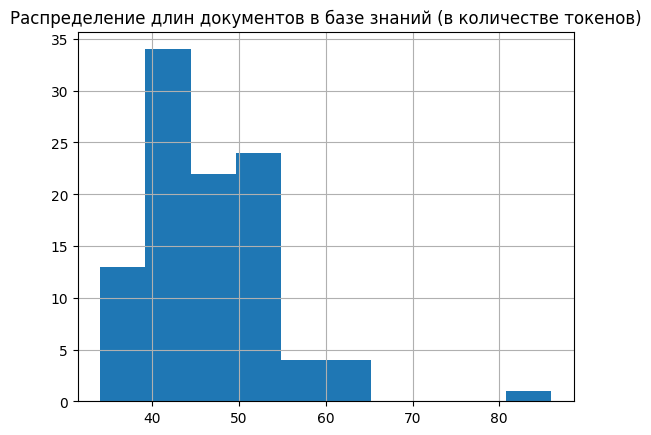

In [ ]:
from sentence_transformers import SentenceTransformer

# Чтобы получить значение max sequence_length, мы запросим базовый объект `SentenceTransformer`, используемый в RecursiveCharacterTextSplitter
model_name = "BAAI/bge-small-en"
print(f"Model's maximum sequence length: {SentenceTransformer(model_name).max_seq_length}")

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_name)
lengths = [len(tokenizer.encode(doc.page_content)) for doc in tqdm(documents)]

# Построим график распределения длин документов, подсчитываемых как количество токенов
fig = pd.Series(lengths).hist()
plt.title("Распределение длин документов в базе знаний (в количестве токенов)")
plt.show()

В контекст модели (512) наши данные явно попадают с огромным запасом.

In [ ]:
from langchain_community.document_loaders import TextLoader

from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy

from langchain_text_splitters import CharacterTextSplitter
from langchain_chroma import Chroma

# Load the document, split it into chunks, embed each chunk and load it into the vector store.

text_splitter = CharacterTextSplitter(chunk_size=100, chunk_overlap=0)
documents = text_splitter.split_documents(RAW_KNOWLEDGE_BASE)
model_name = "BAAI/bge-small-en"
model_kwargs = {"device": device}
encode_kwargs = {"normalize_embeddings": True}
embeddings = HuggingFaceEmbeddings(
    model_name=model_name,
    multi_process=False,
    model_kwargs=model_kwargs,
    encode_kwargs={"normalize_embeddings": True})  # `True` для косинусного сходства
db = Chroma.from_documents(documents, embeddings, collection_metadata={"hnsw:space": "cosine"})

<ipython-input-42-2a6fa2e64e70>:16: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [ ]:
user_query = "Where I can find gazebo?" # на волжской набережной в Ярославле
query_vector = embeddings.embed_query(user_query)

In [ ]:
from sklearn.decomposition import PCA

# Access the internal ChromaDB collection
collection = db._collection

# Get all embeddings (as NumPy arrays)
results = collection.get(include=["embeddings"])

embeddings_list = results["embeddings"]  # This is a list of embedding vectors

print(f"Got {len(embeddings_list)} embeddings")

embedding_projector_pca = PCA(n_components=2)

embeddings_2d = embeddings_list + [query_vector]

documents_projected_pca = embedding_projector_pca.fit_transform(np.array(embeddings_2d))

Got 102 embeddings


In [ ]:
def build_cool_graph(documents_projected, docs_processed=documents, user_query=user_query, method_name="PCA"):
  df = pd.DataFrame.from_dict(
      [
          {
              "x": documents_projected[i, 0],
              "y": documents_projected[i, 1],
              "source": docs_processed[i].metadata["name"],
              "extract": docs_processed[i].page_content[:100] + "...",
              "symbol": "circle",
              "size_col": 4,
          }
          for i in range(len(docs_processed))
      ]
      + [
          {
              "x": documents_projected[-1, 0],
              "y": documents_projected[-1, 1],
              "source": "User query",
              "extract": user_query,
              "size_col": 20, #100
              "symbol": "star",
          }
      ]
  )

  # Визуализируем эмбеддинги
  fig = px.scatter(
      df,
      x="x",
      y="y",
      color="source",
      hover_data="extract",
      size="size_col",
      symbol="symbol",
      color_discrete_map={"User query": "black"},
      width=1000,
      height=700,
  )
  fig.update_traces(
      marker=dict(opacity=1, line=dict(width=0, color="DarkSlateGrey")),
      selector=dict(mode="markers"),
  )
  fig.update_layout(
      legend_title_text="<b>Источник чанка</b>",
      title=f"<b>2D-проекция чанков с помощью {method_name}</b>",
  )
  fig.show()

In [ ]:
build_cool_graph(documents_projected_pca)

In [ ]:
embedding_projector_umap = umap.UMAP(n_components=2)

documents_projected_umap = embedding_projector_umap.fit_transform(np.array(embeddings_2d))

build_cool_graph(documents_projected_umap, method_name="UMAP")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



Беседка на Волжской набережной - единственное описание, в котором есть слово газебо, оно оказалось недалеко от запроса в обычном PCA, а вот umap засунул его в группу Владимира.

In [ ]:
print(f"\nStarting retrieval for {user_query=}...")
retrieved_docs = db.similarity_search(query=user_query, k=5)
print("\n==================================Top document==================================")
print(retrieved_docs[0].page_content)
print("==================================Metadata==================================")
print(retrieved_docs[0].metadata)


Starting retrieval for user_query='Where I can find gazebo?'...

==================================Top document==================================
The Conversation on the Volzh waterfront in city of Yaroslavl is a Conversation on the Volzh waterfront, its photo could be described as people walking around a gazebo with a green roof and a lake in the background
==================================Metadata==================================
{'city': 'Ярославль', 'image': '...', 'name': 'Беседка на Волжской набережной'}


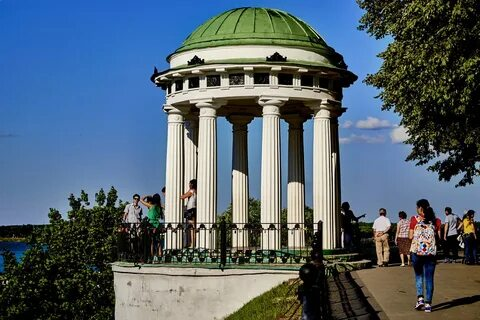

In [ ]:
get_image(retrieved_docs[0].metadata['image'])

Однако поиск ближайших векторов полной размерности выдал нужный результат. Воистину газебо!

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

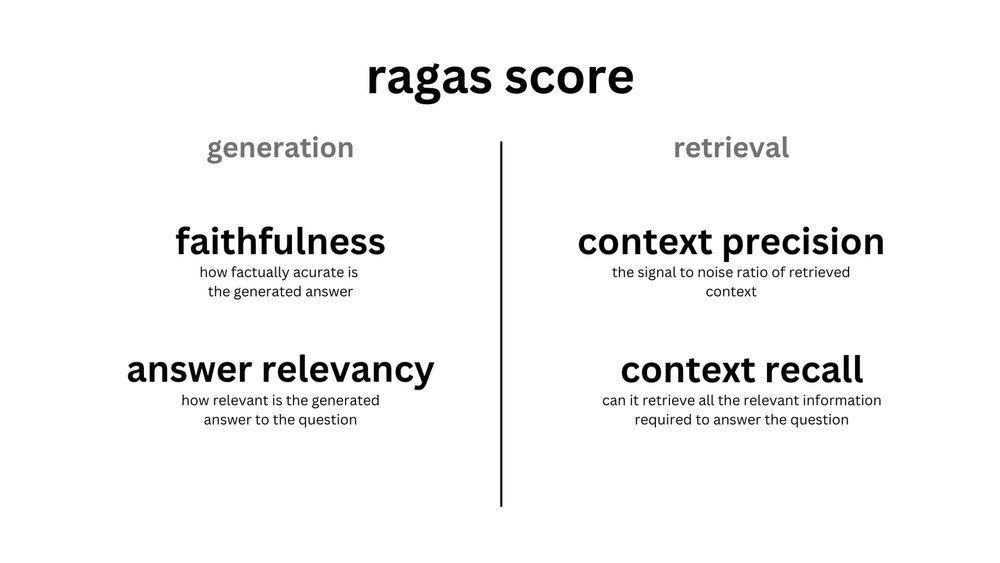

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

Для повышения скорости вычислений возьму маленькую модель TinyLlama.

In [ ]:
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

READER_MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0" # "mistralai/Mistral-7B-Instruct-v0.2" bigger, requires quantization

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)
model = AutoModelForCausalLM.from_pretrained(READER_MODEL_NAME, quantization_config=bnb_config)
tokenizer = AutoTokenizer.from_pretrained(READER_MODEL_NAME)

READER_LLM = pipeline(
    model=model,
    tokenizer=tokenizer,
    task="text-generation",
    do_sample=True,
    temperature=0.2,
    repetition_penalty=1.1,
    return_full_text=False,
    max_new_tokens=500,
)

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Device set to use cuda:0


Проверим, что она работает.

In [ ]:
print(READER_LLM("Where I can find gazebo? Answer:"))

[{'generated_text': ' Gazebos are available in different sizes and shapes, depending on the location. You can find gazebos at garden centers, hardware stores, home improvement stores, outdoor furniture stores, and online retailers. Some popular brands include Suncast, Tuff Shed, and Deckorators.'}]


Зададим промпты для генерации вопросов и ответов.

In [ ]:
prompt_question_in_chat_format = [
    {
        "role": "system",
        "content": """Using the information contained in the context,
    ask a question about it.
    Question should be concise and relevant to the context.
    If the question about context cannot be asked, do not give question.""",
    },
    {
        "role": "user",
        "content": """
    Now here is the context you need to generate question about.

    Context: {context}""",
    },
    ]
question_template = tokenizer.apply_chat_template(prompt_question_in_chat_format, tokenize=False, add_generation_prompt=True)

In [ ]:
prompt_in_chat_format = [
    {
        "role": "system",
        "content": """Using the information contained in the context,
give a comprehensive answer to the question.
Respond only to the question asked, response should be concise and relevant to the question.
Provide the number of the source document when relevant.
If the answer cannot be deduced from the context, do not give an answer.""",
    },
    {
        "role": "user",
        "content": """Context:
{context}
---
Now here is the question you need to answer.

Question: {question}""",
    },
]
answer_template = tokenizer.apply_chat_template(
    prompt_in_chat_format, tokenize=False, add_generation_prompt=True
)

Зададим реранкер.

In [ ]:
RERANKER = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0") #replace model?

artifact.metadata:   0%|          | 0.00/1.63k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/405 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/colbert/utils/amp.py:12: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.



Функция ниже генерирует вопросы и ищет под них контексты в векторной базе данных.

In [ ]:
import langchain_core.messages
from datasets import Dataset
#from ragas import SingleTurnSample
#from ragas import EvaluationDataset

def data_preprocess(documents=documents, question_template=question_template, num_retrieved_docs=10, num_docs_final=5, reranker=RERANKER):
  # your code here
  # question ground_truths answer contexts
  preproc_data = []
  for document in documents:
    dic_doc = {}

    question_generation_prompt = question_template.format(context=document.page_content)

    question = READER_LLM(question_generation_prompt)[0]["generated_text"]
    dic_doc["ground_truths"] = document.page_content

    dic_doc["question"] = question


    retrieved_docs = db.similarity_search(query=user_query, k=num_retrieved_docs)

    #print(retrieved_docs[0])

    relevant_docs = [doc.page_content for doc in retrieved_docs]

    relevant_docs = reranker.rerank(question, relevant_docs, k=num_docs_final)
    relevant_docs = [doc["content"] for doc in relevant_docs]

    relevant_docs = relevant_docs[:num_docs_final]

    #retrieved_docs_text = [doc.page_content for doc in relevant_docs]

    dic_doc["contexts"] = relevant_docs

    context = "\nExtracted documents:\n"
    context += "".join([f"Document {str(i)}:::\n" + doc for i, doc in enumerate(relevant_docs)])

    answer_generation_prompt = answer_template.format(question=dic_doc["question"], context=context)


    dic_doc["answer"] = READER_LLM(answer_generation_prompt)[0]["generated_text"]


    preproc_data.append(dic_doc)

  #preproc_data = Dataset.from_list(preproc_data)

  return preproc_data

Для расчета релевантности ответа сначала нужно нагенерировать еще несколько ответов на вопрос и затем усреднить косинусные сходства между ними и вопросом, что и делает функция ниже.

In [ ]:
import numpy as np

def calculate_answer_relevancy(data, answer_template=answer_template, embedding_model=embeddings, i=2): #по умолчанию, конечно, три ответа нужно, но для скорости ограничусь двумя
  # your code here
  # evaluation_data should be a Dataset with these columns:
  # "question", "answer", "contexts"

  #data = Dataset.from_list(preproc_data)
  #relevant_data = data.remove_columns(['ground_truths'])
  all_relevancies = []
  all_answers = {}
  for dic in tqdm(data):
    q_embedding = embedding_model.embed_query(dic["question"])
    context = "\nExtracted documents:\n"
    context += "".join([f"Document {str(i)}:::\n" + doc for i, doc in enumerate(dic["contexts"])])

    answer_generation_prompt = answer_template.format(question=dic["question"], context=context)
    dic_embeddings = [np.dot(embedding_model.embed_query(dic["answer"]), q_embedding)]

    answers_dict = {'Truth': dic['ground_truths'], 'Model_answers': [dic["answer"]]}

    for _ in range(i-1): # один ответ уже дан при предобработке
      answer = READER_LLM(answer_generation_prompt)[0]["generated_text"]

      # заданный эмбеддинг уже усредняет векторы, так что хватит и обычного скалярного произведения
      dic_embeddings.append(np.dot(embedding_model.embed_query(answer), q_embedding))
      answers_dict['Model_answers'].append(answer)

    all_answers[dic["question"]] = answers_dict

    all_relevancies.append(sum(dic_embeddings) / i)

  result = sum(all_relevancies) / len(all_relevancies)
  print("Answer Relevancy Score:", result) #result['answer_relevancy']

  return result, all_answers

# Протестируйте ваш RAG (3 балла)

In [ ]:
# your code here
preproc_data = data_preprocess()
clear_output()

In [ ]:
import pickle

with open('/content/DLS_RAG_translated.pkl', 'wb') as f:
    pickle.dump(preproc_data, f)

In [ ]:
result, all_answers = calculate_answer_relevancy(preproc_data)

  0%|          | 0/102 [00:00<?, ?it/s]

Answer Relevancy Score: 0.8937737105151502


In [ ]:
import pickle

with open('/content/DLS_RAG_2answers.pkl', 'wb') as f:
    pickle.dump(all_answers, f)

Релевантность получилась высокой, 0.89. Посмотрим на первые пять ответов.

In [ ]:
i = 0
for key, value in all_answers.items():
  print('Q:', key)
  print('True A:', value["Truth"])
  for j, k in enumerate(value['Model_answers']):
    print(f'Model A{j+1}:', k)
  print()
  i += 1
  if i > 5:
    break

Q: Question: Can you summarize the context provided for "The Celebrity Church in city of Yaroslavl"?
True A: The Celebrity Church in city of Yaroslavl is a The Fortress Tower in Jaroslava, its photo could be described as cars are parked in front of a large white building with a golden dome
Model A1: The context provided for "The Celebrity Church in city of Yaroslavl" includes the following documents:
- The Governor &apos; s House (Yaroslavl): A Governor &apos; s House (Yaroslavl), which has a fountain in the middle of a courtyard with a building in the background.
- The Jaroslav Museum of Art (Guarantor &apos; s House): An Art Museum in Jaroslava, which has a fountain in the middle of a courtyard with a building in the background.
- The Conversation on the Volzh waterfront in city of Yaroslavl: A Conversation on the Volzh waterfront, which has people walking around a gazebo with a green roof and a lake in the background.
- The Church for the Christmas of the Lady of God. in city of Niz

Ответы модели от генерации к генерации меняются незначительно, форма ответов хорошая, а вот по существу ответов есть вопросы, модель часто подмешивает в ответ контексты других объектов и потому неправильно описывает целевые достопримечтельности. Это можно попробовать исправить путем добавления нескольких описаний для каждого объекта.

# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

Рассчитаю context precision без использования моделей, просто по косинусным расстояниям. План такой: получить эмбеддинги контекстов, предложенных нашей векторной базой данных, подсчитать их косинусное сходство с эмбеддингом правильного контекста (ground truth) и затем вычислить долю контекстов, которые схожи с правильным более, чем пороговое значение (threshold). Для получения результата по всему датасету усредню все полученные доли.

In [ ]:
# your code here
from sklearn.metrics.pairwise import cosine_similarity

def calculate_context_precision(data, embedding_model=embeddings, threshold=0.9):
  result = 0
  for dic in data:
    reference_embedding = embedding_model.embed_query(dic["ground_truths"])
    context_embeddings = embedding_model.embed_documents(dic["contexts"])
    results = cosine_similarity(context_embeddings, [reference_embedding]).flatten()

    relevant_flags = results >= threshold


    context_precision = sum(relevant_flags) / len(dic["contexts"])

    result += context_precision
  result /= len(data) # средняя доля релевантных контекстов

  print("Context Precision Score:", result)

  return result


In [ ]:
result = calculate_context_precision(preproc_data, threshold=0.8)

Context Precision Score: 0.9862745098039215


In [ ]:
result = calculate_context_precision(preproc_data, threshold=0.9)

Context Precision Score: 0.10392156862745097


In [ ]:
result = calculate_context_precision(preproc_data, threshold=0.95)

Context Precision Score: 0.023529411764705882


Как видно, основная часть контекстов релевантна более чем на 80%, но менее, чем на 95%. Это неудивительно, т.к. большинство объектов - это здания, но каждый контекст описывает свой уникальный объект. Для повышения релевантности можно добавить несколько описаний одного объекта, но это увеличит размер датасета.